In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


sns.set(style="whitegrid")

#load and display a couple rows of the cleaned dataset
df = pd.read_csv("../data/processed/Cleaned-Customer-Data.csv")
df.head()

,Customer ID,Title,First Name,Middle Name,Last Name,Suffix,Street Address1,Street Address2,City-ZipCode-State,Birth Date,...,Avg Monthly Spend,eBook Subscriber Flag,Occupation_Management,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual,Education Level_Graduate Degree,Education Level_High School,Education Level_Partial College,Education Level_Partial High School
0,11000,NaN,Jon,V,Yang,NaN,3761 N. 14th St,NaN,Cleveland-44101-Ohio,4/8/66,...,89,0,False,False,True,False,False,False,False,False
1,11001,NaN,Eugene,L,Huang,NaN,2243 W St.,NaN,Seattle-98101-Washington,5/14/65,...,117,1,False,False,True,False,False,False,False,False
2,11002,NaN,Ruben,NaN,Torres,NaN,5844 Linden Land,NaN,Omaha-68101-Nebraska,8/12/65,...,123,0,False,False,True,False,False,False,False,False
3,11003,NaN,Christy,NaN,Zhu,NaN,1825 Village Pl.,NaN,Fort Worth-76101-Texas,2/15/68,...,50,0,False,False,True,False,False,False,False,False
4,11004,NaN,Elizabeth,NaN,Johnson,NaN,7553 Harness Circle,NaN,Oakland-94601-California,8/8/68,...,95,1,False,False,True,False,False,False,False,False


In [19]:
#dataset overview
print("Dataset dimensions:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nDataset Stats:")
df.describe().round(2)

Dataset dimensions: (15639, 27)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15639 entries, 0 to 15638
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Customer ID                          15639 non-null  int64 
 1   Title                                78 non-null     object
 2   First Name                           15639 non-null  object
 3   Middle Name                          9030 non-null   object
 4   Last Name                            15639 non-null  object
 5   Suffix                               2 non-null      object
 6   Street Address1                      15639 non-null  object
 7   Street Address2                      269 non-null    object
 8   City-ZipCode-State                   15639 non-null  object
 9   Birth Date                           15639 non-null  object
 10  Gender                               15639 non-null  object

,Customer ID,Home Owner Status,Number of Cars Owned,Number of Children At Home,Total Number of Children,Annual Income,Avg Monthly Spend,eBook Subscriber Flag
count,15639.00,15639.00,15639.00,15639.00,15639.00,15639.00,15639.00,15639.00
mean,20242.18,0.67,1.42,0.80,1.87,74720.93,68.03,0.30
std,5347.87,0.47,1.09,1.32,1.61,37544.79,20.51,0.46
min,11000.00,0.00,0.00,0.00,0.00,9482.00,22.00,0.00
25%,15597.50,0.00,1.00,0.00,0.00,46476.50,51.00,0.00
50%,20227.00,1.00,1.00,0.00,2.00,72663.00,66.00,0.00
75%,24871.50,1.00,2.00,1.00,3.00,101204.50,81.00,1.00
max,29482.00,1.00,4.00,5.00,5.00,196511.00,132.00,1.00


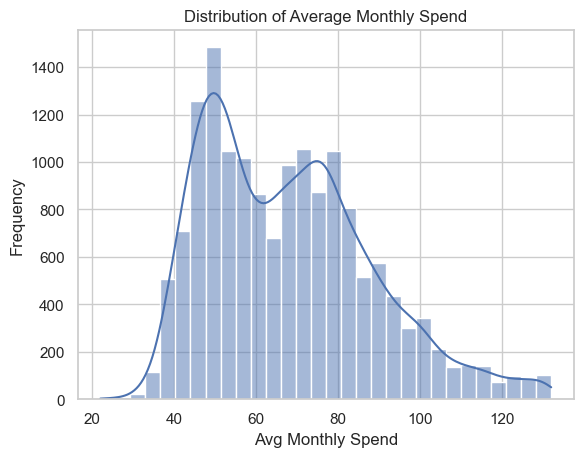

In [20]:
#visualize distribution of avg monthly spend
plt.figure()
sns.histplot(df['Avg Monthly Spend'], bins=30, kde=True)
plt.title("Distribution of Average Monthly Spend")
plt.xlabel("Avg Monthly Spend")
plt.ylabel("Frequency")
plt.show()

### Insights

The Distribution of Average Monthly Spend is slightly right-skewed. While the primary peak occurs around 50, the tail of the graph doesn't drop off immediately to the right. Instead, it gradually decreases as the Avg Montly Spend goes up to 130. This indicates the presence of higher spending customers.

While most customers are spending between 40 and 80, there is a group of customers spending significantly more. This suggests there are high value customers willing to spend more than the average customer.

Additionally, a secondary peak between 65 and 85 suggests the presence of a mid-to-high spending group of customers. This suggests that customer spending may be clustered into multiple tiers rather than following a normal distribution.

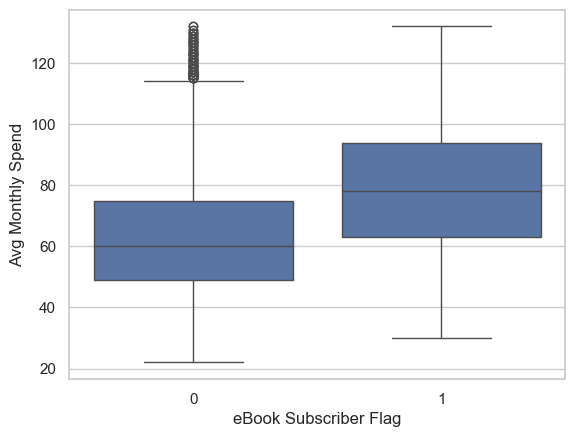

In [21]:
sns.boxplot(x="eBook Subscriber Flag", y="Avg Monthly Spend", data=df)
plt.show()

### Insights

*0 represents non-subscribers*  
*1 represents subscribers*

Customers who are subscribed to the eBook service exhibit a noticeably higher median Average Monthly Spend compared to non-subscribers. The distribution for subscribers is shifted upward, indicating a consistent higher spending.

While non-subscribers include some high-spending outliers, their overall spending remains lower compared to subscribers. This suggests that subscription status is strongly associated with increased customer spending, and that subscribers are more likely to fall into mid-to-high spending tiers.

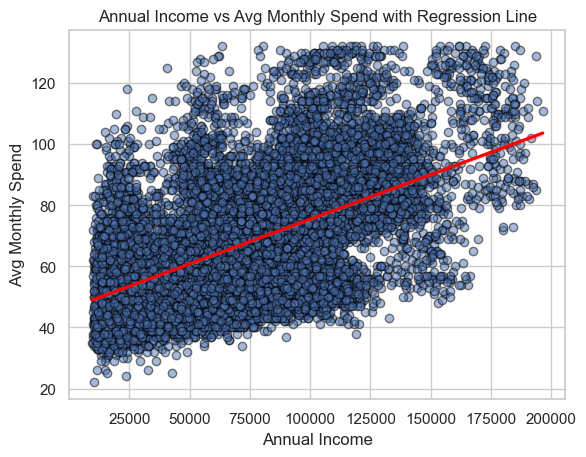

In [22]:
plt.figure()
sns.regplot(x="Annual Income", y="Avg Monthly Spend", data=df, scatter_kws={'alpha':0.5, 'edgecolor':'black'}, line_kws={'color':'red'})
plt.title("Annual Income vs Avg Monthly Spend with Regression Line")
plt.xlabel("Annual Income")
plt.ylabel("Avg Monthly Spend")
plt.show()

### Insights

There is a clear positive relationship between Annual Income and Average Monthly Spend, where customers with higher income generally spend more than customers with lower income. However, the relationship is not perfectly linear, as there is significant variability in spending across all income levels.

Additionally, the data forms multiple clusters, suggesting that factors other than income may also influence spending behavior.

Overall, Annual Income is a strong predictor for customer spending; however, other factors should also be considered for more accurate modeling.

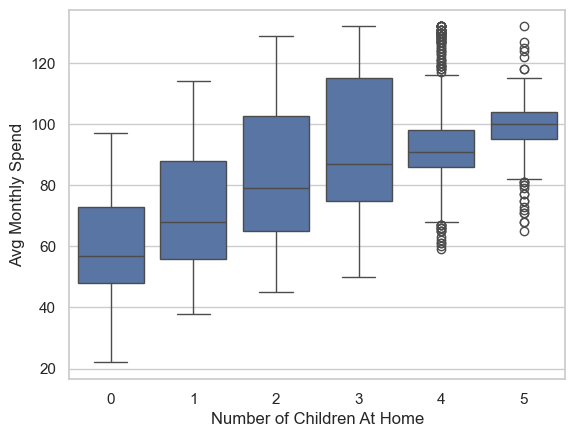

In [23]:
sns.boxplot(x="Number of Children At Home", y="Avg Monthly Spend", data=df)
plt.show()

### Insights

There is a clear positive relationship between the Number of Children at Home and Average Monthly Spend. This shows spending increases steadily from 0 to 3 children and starts to level off beyond 3 children. This shows that the spending increase associated with household size diminishes as a household grows past 3 children.

Additionally, variability in spending is higher among household with 4-5 children, indicating that households with more than 3 children have more diverse purchasing behaviors.

Overall, the number of children is a strong factor influencing customer spending as there is likely an increase in household demand.

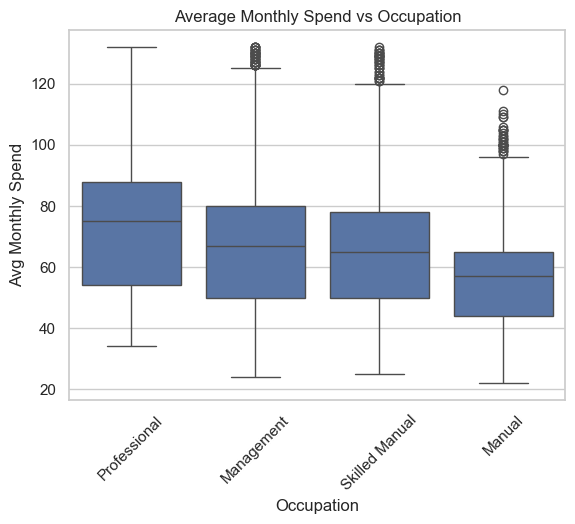

In [24]:
occupation_cols = [col for col in df.columns if "Occupation_" in col]

df["Occupation"] = df[occupation_cols].idxmax(axis=1)
df["Occupation"] = df["Occupation"].str.replace("Occupation_", "")

#df["Occupation"].unique()

plt.figure()
sns.boxplot(x="Occupation", y="Avg Monthly Spend", data=df)
plt.xticks(rotation=45)
plt.title("Average Monthly Spend vs Occupation")
plt.xlabel("Occupation")
plt.ylabel("Avg Monthly Spend")
plt.show()

### Insights

Avg Monthly Spend varies across occupations, with Professional roles showing the highest median spending, while Manual occupations have the lowest. Management and Skilled Manual occupations display similar median spending level in between both Professional and Manual occupations. 

In terms of maximum spending, Professional roles have the highest values, followed by Management, Skilled Manual, and Manual occupations. Additionally, Management and Skilled Manual occupations show very similar quartiles and minimum values, indicating similar spending behavior between the two. However, Management reaches a higher maximum spending value, while Skilled Manual exhibits a greater number of high-spending outliers. This suggests that although the peak spending is higher in Management, Skilled Manual occupations have a broader group of high value customers.  

Overall, occupation shows clear differences in customer spending behavior, with distinct patterns observed across job categories. These patterns highlight the importance of considering occupation when analyzing customer purchasing trends. 


In [27]:
df.corr(numeric_only=True)["Avg Monthly Spend"].sort_values(ascending=False)

Avg Monthly Spend                      1.000000
Number of Children At Home             0.597019
Annual Income                          0.535294
Total Number of Children               0.378063
eBook Subscriber Flag                  0.357481
Number of Cars Owned                   0.217989
Occupation_Professional                0.200647
Occupation_Management                  0.154457
Home Owner Status                      0.138949
Education Level_Graduate Degree       -0.001381
Education Level_Partial College       -0.008036
Customer ID                           -0.029823
Occupation_Skilled Manual             -0.048801
Education Level_High School           -0.055454
Education Level_Partial High School   -0.108715
Occupation_Manual                     -0.218580
Name: Avg Monthly Spend, dtype: float64

### Insights

Correlation analysis demonstrates that several variables are strongly associated with Avg Monthly Spend, with the Number of Children at Home (~0.60) and Annual Income (~0.54) having the strongest relationship. This indicates that both the Number of Children at Home and Annual Income are key drivers of customer spending. 

Total Number of children (~0.38) exhibit moderate positive correlation which supports the earlier observation that larger households tend of spend more than smaller households. The eBook Subscriber Flag (~0.36) also shows moderate positive correlation, implying that customers who are eBook subscribers also tend to spend more than non-subscribers. 

Occupation related variables show smaller effects, with Professional and Management roles positively correlated with spending, while Skilled Manual and Manual related occupations show a negative relationship. This suggests that higher skilled occupations are genearlly associated with higher spending, while lower skilled occupations tend to spend less on average.

Overall, these results reinforce that customer spending is influenced by a combination of demographic, socioecondomic, and behavrioal factors rather than a single dominant variable. 